In [1]:
import os
import json
import random
import numpy as np
import torch
import math
import torch.nn as nn
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset, TensorDataset
import torch.nn.functional as F
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

from gap.classifiers import ScalableResNetLite
from gap.adv import AdversarialAttacker
from gap.spectral import SpectralAnalyzer
from gap.purify import purify_ddpm, purify

#from gap.purification.train_scriptv2 import GaussianDiffusion, HyperConfig, UNetLite
from gap.purification.train_scriptv3 import ScoreSDEContinuous, HyperConfig, UNetLite
from gap.purification.dae_train_script import HyperConfig as DAEHyperConfig
from gap.purification.dae_train_script import ShallowDAE

In [2]:
# Set up environment, choose model to load
device = (
    "cuda"
    if torch.cuda.is_available()
    else "mps"
    if torch.backends.mps.is_available()
    else "cpu"
)
print(f"Using device: {device}")

RUN_DIR = "../saved_models"

clf_metadata_path = os.path.join(RUN_DIR, "cifar10_metadata.json")
clf_weights_path = os.path.join(RUN_DIR, "cifar10_classifier.pth")

dae_metadata_path = os.path.join(RUN_DIR, "cifar10_dae/best_model.pt")
#dm_metadata_path = os.path.join(RUN_DIR, "cifar10_diffusion/best_model.pt")
dm_metadata_path = os.path.join(RUN_DIR, "cifar10_sde/best_model.pt")

with open(clf_metadata_path, "r") as f:
    clf_best_model = json.load(f)

clf_best_config = clf_best_model["model_config"]
print(f"Loaded classifier config: {clf_best_config}")

Using device: mps
Loaded classifier config: {'lr': 0.0001838809343739058, 'channels': 96, 'depth': 4, 'optimizer': 'adam', 'weight_decay': 0.0005}


In [3]:
# Instantiate the model using the weights and metadata loaded
clf_trained_model = ScalableResNetLite(
    num_classes=10, channels=clf_best_config["channels"], depth=clf_best_config["depth"]
).to(device)

clf_trained_model.load_state_dict(
    torch.load(clf_weights_path, map_location=device, weights_only=True)
)
clf_trained_model.eval()
print("Classification model loaded successfully!")

Classification model loaded successfully!


In [4]:
def load_diffusion_model(checkpoint_path, in_channels=3, device="cpu"):
    checkpoint = torch.load(checkpoint_path, map_location=device)
    
    hcfg_dict = checkpoint["hcfg"]
    hcfg = HyperConfig(**hcfg_dict)
    print(f"Loaded Hyperparameters: {hcfg}")
    
    unet = UNetLite(
        in_channels=in_channels,
        base_channels=hcfg.base_channels,
        channel_mults=hcfg.channel_mults,
        num_res_blocks=hcfg.num_res_blocks,
        dropout=hcfg.dropout
    ).to(device)
    
    unet.load_state_dict(checkpoint["model"])
    unet.eval()
    
    diffusion = ScoreSDEContinuous(unet).to(device)
    diffusion.eval()
    
    return diffusion, hcfg

def load_dae_model(checkpoint_path, in_channels=3, device="cpu"):
    checkpoint = torch.load(checkpoint_path, map_location=device)

    hcfg_dict = checkpoint["hcfg"]
    hcfg = DAEHyperConfig(**hcfg_dict)
    print(f"Loaded Hyperparamters: {hcfg}")

    dae = ShallowDAE(in_channels=in_channels,
        base_channels=hcfg.base_channels,
        bottleneck_dim=hcfg.bottleneck_dim,
        dropout=hcfg.dropout,
        noise_std=hcfg.noise_std
    ).to(device)

    dae.load_state_dict(checkpoint["model"])
    dae.eval()

    return dae, hcfg

class SBMInferenceWrapper(nn.Module):
    """
    Wraps the trained UNetLite. 
    Intercepts the (x, sigma) call from your purify.py script,
    translates sigma into continuous time t, and passes it to the UNet.
    """
    def __init__(self, unet, sigma_min, sigma_max):
        super().__init__()
        self.unet = unet
        self.sigma_min = sigma_min
        self.sigma_max = sigma_max
        
        # Precompute logs for fast translation
        self.log_sig_min = math.log(sigma_min)
        self.log_sig_max = math.log(sigma_max)

    def forward(self, x, sigma):
        # FIX: Flatten sigma from (Batch, 1) to (Batch,) to prevent 5D broadcasting explosions
        sigma = sigma.view(-1)
        
        # 1. Translate raw sigma to t in [0, 1]
        log_sigma = torch.log(sigma)
        t = (log_sigma - self.log_sig_min) / (self.log_sig_max - self.log_sig_min)
        
        # Clamp to [0, 1] just to be safe from floating point rounding errors
        t = torch.clamp(t, 0.0, 1.0)
        
        # 2. Pass to the UNet
        return self.unet(x, t)
 

def load_sbm(checkpoint_path, in_channels=3, device="cpu"):
    """
    Loads the saved model and returns it wrapped for sigma-conditioning.
    """
    checkpoint = torch.load(checkpoint_path, map_location=device, weights_only=True)
    
    hcfg_dict = checkpoint["hcfg"]
    # Reconstruct the config
    hcfg = HyperConfig(**hcfg_dict)
    print(f"Loaded Hyperparameters: {hcfg}")
    
    # 1. Instantiate the raw UNet
    unet = UNetLite(
        in_channels=in_channels,
        base_channels=hcfg.base_channels,
        channel_mults=hcfg.channel_mults,
        num_res_blocks=hcfg.num_res_blocks,
        dropout=hcfg.dropout
    ).to(device)
    
    # 2. Load the weights
    unet.load_state_dict(checkpoint["model"])
    unet.eval()
    
    # 3. Wrap it with the sigma boundaries saved during training
    wrapped_model = SBMInferenceWrapper(
        unet, 
        sigma_min=checkpoint["sigma_min"], 
        sigma_max=checkpoint["sigma_max"]
    ).to(device)
    
    return wrapped_model, hcfg

In [5]:
#dm, dm_config = load_diffusion_model(RUN_DIR + "/cifar10_diffusion/best_model.pt")
dm, dm_config = load_sbm(RUN_DIR + "/cifar10_sde/best_model.pt")
dae, dae_config = load_dae_model(RUN_DIR + "/cifar10_dae/best_model.pt")

Loaded Hyperparameters: HyperConfig(base_channels=32, channel_mults=(1, 2, 2), num_res_blocks=2, dropout=0.1, lr=0.0003, batch_size=64, num_timesteps=500)
Loaded Hyperparamters: HyperConfig(base_channels=32, bottleneck_dim=256, dropout=0.0, lr=0.0003, batch_size=32, noise_std=0.05)


In [6]:
transform = transforms.Compose(
    [
        transforms.ToTensor(),
    ]
)

test_data = datasets.CIFAR10(
    root="../datasets", train=False, download=True, transform=transform
)

# There are 10000 test samples to choose from
test_subset = Subset(test_data, range(10000))
eval_loader = DataLoader(test_subset, batch_size=128, shuffle=False)
print("Data loaded successfully! Ready for adversarial generation.")

Data loaded successfully! Ready for adversarial generation.


/Users/austinb.dev.bc/Projects/gap/.venv/lib/python3.12/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


Next steps: **Prepare the data for purification**
- Perform inference on the test data loaded with the loaded classification model.
- Identify all of the samples that were classified correctly and take that subset of samples.
- Generate adversarial data examples for all of those correctly classified samples from the test data. Use both PGD and FGSM.

In [7]:
attacker = AdversarialAttacker(clf_trained_model, device)

original_loader = attacker.get_correct_subset_loader(eval_loader)

Filtering for correctly classified samples...
Filtering complete. Accuracy 86.19.


In [8]:
fgsm_loader = attacker.generate_adversarial_dataset(
    original_loader, attack_type="fgsm", epsilon=1 / 255
)
pgd_loader = attacker.generate_adversarial_dataset(
    original_loader, attack_type="pgd", epsilon=1 / 255
)

Generating FGSM adversarial examples...
Generating PGD adversarial examples...


In [9]:
os.makedirs("../datasets/adversarial", exist_ok=True)

fgsm_images, fgsm_labels = fgsm_loader.dataset.tensors
pgd_images, pgd_labels = pgd_loader.dataset.tensors

torch.save(
    {"images": fgsm_images, "labels": fgsm_labels},
    "../datasets/adversarial/cifar10_fgsm_eps0.03.pt",
)

torch.save(
    {"images": pgd_images, "labels": pgd_labels},
    "../datasets/adversarial/cifar10_pgd_eps0.03.pt",
)

print("Adversarial tensors saved successfully to ../datasets/adversarial/")

Adversarial tensors saved successfully to ../datasets/adversarial/


We now can load the adversarial examples and their original labels directly from storage.

In [8]:
fgsm_data_dict = torch.load(
    "../datasets/adversarial/cifar10_fgsm_eps0.03.pt", weights_only=True
)

fgsm_dataset = TensorDataset(fgsm_data_dict["images"], fgsm_data_dict["labels"])
fgsm_loader = DataLoader(fgsm_dataset, batch_size=128, shuffle=False)

pgd_data_dict = torch.load(
    "../datasets/adversarial/cifar10_pgd_eps0.03.pt", weights_only=True
)

pgd_dataset = TensorDataset(pgd_data_dict["images"], pgd_data_dict["labels"])
pgd_loader = DataLoader(pgd_dataset, batch_size=128, shuffle=False)

In [9]:
CIFAR10_CLASSES = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

def get_predictions_and_probs(model, dataloader, device):
    """Iterates through the dataloader to get true labels, predictions, and softmax probabilities."""
    model.eval()
    all_labels = []
    all_preds = []
    all_probs = []
    
    with torch.no_grad():
        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            probs = F.softmax(outputs, dim=1)
            preds = torch.argmax(probs, dim=1)
            
            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())
            
    return np.array(all_labels), np.array(all_preds), np.array(all_probs)

def print_metrics(dataset_name, y_true, y_pred, y_prob):
    """Calculates and prints comprehensive metrics."""
    acc = accuracy_score(y_true, y_pred)
    # Using macro average to treat all classes equally
    prec = precision_score(y_true, y_pred, average='macro', zero_division=0)
    rec = recall_score(y_true, y_pred, average='macro', zero_division=0)
    f1 = f1_score(y_true, y_pred, average='macro', zero_division=0)
    # ROC-AUC for multiclass requires the 'ovr' (One-vs-Rest) strategy
    roc_auc = roc_auc_score(y_true, y_prob, multi_class='ovr', average='macro')
    
    print(f"--- {dataset_name} Performance ---")
    print(f"Accuracy:  {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall:    {rec:.4f}")
    print(f"F1-Score:  {f1:.4f}")
    print(f"ROC-AUC:   {roc_auc:.4f}\n")

In [10]:
def diff_purify_dataset(dataloader, model, clf_model, device):
    # t_max_ratio controls how far into the diffusion process we go.
    # 0.15 to 0.20 is usually the sweet spot. Too low = adversarial 
    # noise survives. Too high = image structure is destroyed.
    ratios = [0.0125, 0.025, 0.0375, 0.05]
    best_ratio = 0.05
    best_acc = -1
    best_purified_images = []
    best_labels_list = []

    for ratio in ratios:
        purified_images = []
        labels_list = []

        for images, labels in dataloader:
            # Get the full trajectory, take the last frame
            traj = purify_ddpm(images, model, t_max_ratio=ratio, device=device)
            # traj is returned as a numpy array of shape [steps, B, C, H, W]
            final_step = torch.tensor(traj[-1], dtype=torch.float32) 
            # Ensure shape integrity for batches of 1
            if final_step.dim() == 3:
                final_step = final_step.unsqueeze(0) 
            # Clamp to [-1, 1] just in case the reverse process drifted slightly
            final_step = torch.clamp(final_step, -1.0, 1.0)

            purified_images.append(final_step)
            labels_list.append(labels)

        diff_purified_dataset = TensorDataset(torch.cat(purified_images), torch.cat(labels_list))
        diff_purified_loader = DataLoader(diff_purified_dataset, batch_size=128, shuffle=False)

        y, preds, _ = get_predictions_and_probs(clf_model, diff_purified_loader, device)
        acc = accuracy_score(y, preds)
        print(f"Ratio: {ratio}. Accuracy: {acc}")
        if acc > best_acc:
            best_purified_images = purified_images
            best_labels_list = labels_list
            best_ratio = ratio
            best_acc = acc

    print(f"Best Ratio: {best_ratio}. Best Accuracy: {best_acc}")
    return torch.cat(best_purified_images), torch.cat(best_labels_list)


def sbm_purify_dataset(dataloader, model, clf_model, device):
    # Ensure models are on the correct device and in eval mode
    model = model.to(device)
    clf_model = clf_model.to(device)
    model.eval()
    clf_model.eval()

    # For SBM, instead of sweeping a ratio of timesteps, we sweep over the 
    # maximum noise level (sigma) we start our annealed Langevin dynamics from.
    max_sigmas = [0.05, 0.1, 0.15, 0.2]
    best_sigma = 0.05
    best_acc = -1
    best_purified_images = []
    best_labels_list = []

    with torch.no_grad():
        for max_sigma in max_sigmas:
            purified_images = []
            labels_list = []

            # Create an annealing schedule from max_sigma down to a small noise level (0.01)
            # You can adjust the 'steps' argument to control how gradual the annealing is
            sigmas = torch.linspace(max_sigma, 0.01, steps=5, device=device)

            for images, labels in dataloader:
                # Call the unified purify function from your purify.py
                # simple=False triggers your purify_annealed logic
                traj = purify(
                    x_adv=images, 
                    model=model, 
                    sigmas=sigmas, 
                    device=device, 
                    steps_per_sigma=10,  # Hyperparameter: steps per noise level
                    lr=0.01,             # Hyperparameter: Langevin step size
                    simple=False
                )
                
                # traj is returned as a numpy array of shape [steps, B, C, H, W]
                final_step = torch.tensor(traj[-1], dtype=torch.float32) 
                
                # Ensure shape integrity for batches of 1
                if final_step.dim() == 3:
                    final_step = final_step.unsqueeze(0) 
                    
                # Clamp to [-1, 1] just in case the reverse process drifted slightly
                final_step = torch.clamp(final_step, -1.0, 1.0)

                purified_images.append(final_step.cpu())
                labels_list.append(labels.cpu())

            # Evaluate the purified dataset
            diff_purified_dataset = TensorDataset(torch.cat(purified_images), torch.cat(labels_list))
            diff_purified_loader = DataLoader(diff_purified_dataset, batch_size=128, shuffle=False)

            y, preds, _ = get_predictions_and_probs(clf_model, diff_purified_loader, device)
            acc = accuracy_score(y, preds)
            print(f"Max Sigma: {max_sigma:.4f} | Accuracy: {acc:.4f}")
            
            # Track the best performing schedule
            if acc > best_acc:
                best_purified_images = purified_images
                best_labels_list = labels_list
                best_sigma = max_sigma
                best_acc = acc

    print(f"\n--- SBM Purification Complete ---")
    print(f"Best Max Sigma: {best_sigma}. Best Accuracy: {best_acc}")
    return torch.cat(best_purified_images), torch.cat(best_labels_list)



def dae_purify_dataset(dataloader, model, clf_model, device):
    # Explicitly move models to the target device (CPU, CUDA, or MPS)
    model = model.to(device)
    clf_model = clf_model.to(device)
    
    model.eval()
    clf_model.eval()
    
    # We sweep over a few noise scales. 0.0 means a direct forward pass.
    # Higher values add stochastic noise to break the adversarial gradients before reconstruction.
    noise_stds = np.linspace(0, 0.1, 11)
    best_std = 0.0
    best_acc = -1
    best_purified_images = []
    best_labels_list = []

    with torch.no_grad():
        for std in noise_stds:
            purified_images = []
            labels_list = []

            for images, labels in dataloader:
                images = images.to(device)
                
                # 1. Optionally inject noise to disrupt the adversarial attack
                if std > 0:
                    noisy_images = images + torch.randn_like(images) * std
                else:
                    noisy_images = images

                # 2. Single-step manifold projection via the DAE
                recons = model(noisy_images)
                
                # 3. Clamp back to valid image range [-1, 1]
                recons = torch.clamp(recons, -1.0, 1.0)

                purified_images.append(recons.cpu())
                labels_list.append(labels.cpu())

            # Create a temporary loader to evaluate this specific noise scale
            dae_purified_dataset = TensorDataset(torch.cat(purified_images), torch.cat(labels_list))
            dae_purified_loader = DataLoader(dae_purified_dataset, batch_size=128, shuffle=False)

            # Evaluate against the classifier
            y, preds, _ = get_predictions_and_probs(clf_model, dae_purified_loader, device)
            acc = accuracy_score(y, preds)
            
            print(f"Noise STD: {std}. Accuracy: {acc}")
            
            if acc > best_acc:
                best_purified_images = purified_images
                best_labels_list = labels_list
                best_std = std
                best_acc = acc

    print(f"Best Noise STD: {best_std}. Best Accuracy: {best_acc}")
    return torch.cat(best_purified_images), torch.cat(best_labels_list)

In [19]:
dae_purified_fgsm_images, dae_purified_fgsm_labels = dae_purify_dataset(fgsm_loader, dae, clf_trained_model, device)
dae_purified_pgd_images, dae_purified_pgd_labels = dae_purify_dataset(pgd_loader, dae, clf_trained_model, device)

Noise STD: 0.0. Accuracy: 0.6465947325675833
Noise STD: 0.01. Accuracy: 0.649031210117183
Noise STD: 0.02. Accuracy: 0.6485671191553545
Noise STD: 0.03. Accuracy: 0.6528599605522682
Noise STD: 0.04. Accuracy: 0.6555284835827823
Noise STD: 0.05. Accuracy: 0.6530920060331825
Noise STD: 0.06. Accuracy: 0.6439262095370692
Noise STD: 0.07. Accuracy: 0.6351084812623274
Noise STD: 0.08. Accuracy: 0.6110917739877015
Noise STD: 0.09. Accuracy: 0.60064972734656
Noise STD: 0.1. Accuracy: 0.5799976795451909
Best Noise STD: 0.04. Best Accuracy: 0.6555284835827823
Noise STD: 0.0. Accuracy: 0.6620257570483815
Noise STD: 0.01. Accuracy: 0.6627218934911243
Noise STD: 0.02. Accuracy: 0.6650423483002669
Noise STD: 0.03. Accuracy: 0.6671307576284952
Noise STD: 0.04. Accuracy: 0.6658545074834668
Noise STD: 0.05. Accuracy: 0.6659705302239239
Noise STD: 0.06. Accuracy: 0.659821324979696
Noise STD: 0.07. Accuracy: 0.6442742777584407
Noise STD: 0.08. Accuracy: 0.6280310940944425
Noise STD: 0.09. Accuracy: 0.61

In [11]:
dae_purified_save_dir = "../datasets/clean/cifar10/dae"
os.makedirs(dae_purified_save_dir, exist_ok=True)

In [ ]:
torch.save({"images": dae_purified_fgsm_images, "labels": dae_purified_fgsm_labels}, os.path.join(dae_purified_save_dir, "cifar10_purified_fgsm.pt"))
torch.save({"images": dae_purified_pgd_images, "labels": dae_purified_pgd_labels}, os.path.join(dae_purified_save_dir, "cifar10_purified_pgd.pt"))

In [12]:
dae_purified_fgsm_data_dict = torch.load(
    os.path.join(dae_purified_save_dir, "cifar10_purified_fgsm.pt"), weights_only=True
)
dae_purified_fgsm_dataset = TensorDataset(dae_purified_fgsm_data_dict["images"], dae_purified_fgsm_data_dict["labels"])
dae_purified_fgsm_loader = DataLoader(dae_purified_fgsm_dataset, batch_size=128, shuffle=False)

dae_purified_pgd_data_dict = torch.load(
    os.path.join(dae_purified_save_dir, "cifar10_purified_pgd.pt"), weights_only=True
)
dae_purified_pgd_dataset = TensorDataset(dae_purified_pgd_data_dict["images"], dae_purified_pgd_data_dict["labels"])
dae_purified_pgd_loader = DataLoader(dae_purified_pgd_dataset, batch_size=128, shuffle=False)

print("Purified DataLoaders (DAE) are ready.")

Purified DataLoaders (DAE) are ready.


In [11]:
diff_purified_fgsm_images, diff_purified_fgsm_labels = sbm_purify_dataset(fgsm_loader, dm, clf_trained_model, device)
diff_purified_pgd_images, diff_purified_pgd_labels = diff_purify_dataset(pgd_loader, dm, clf_trained_model, device)

Max Sigma: 0.0500 | Accuracy: 0.2208


KeyboardInterrupt: 

In [13]:
diff_purified_save_dir = "../datasets/clean/cifar10/diff"
os.makedirs(diff_purified_save_dir, exist_ok=True)

In [ ]:
torch.save({"images": diff_purified_fgsm_images, "labels": diff_purified_fgsm_labels}, os.path.join(diff_purified_save_dir, "cifar10_purified_fgsm.pt"))
torch.save({"images": diff_purified_pgd_images, "labels": diff_purified_pgd_labels}, os.path.join(diff_purified_save_dir, "cifar10_purified_pgd.pt"))

In [14]:
diff_purified_fgsm_data_dict = torch.load(
    os.path.join(diff_purified_save_dir, "cifar10_purified_fgsm.pt"), weights_only=True
)
diff_purified_fgsm_dataset = TensorDataset(diff_purified_fgsm_data_dict["images"], diff_purified_fgsm_data_dict["labels"])
diff_purified_fgsm_loader = DataLoader(diff_purified_fgsm_dataset, batch_size=128, shuffle=False)

diff_purified_pgd_data_dict = torch.load(
    os.path.join(diff_purified_save_dir, "cifar10_purified_pgd.pt"), weights_only=True
)
diff_purified_pgd_dataset = TensorDataset(diff_purified_pgd_data_dict["images"], diff_purified_pgd_data_dict["labels"])
diff_purified_pgd_loader = DataLoader(diff_purified_pgd_dataset, batch_size=128, shuffle=False)

print("Purified DataLoaders are ready.")

Purified DataLoaders are ready.


In [15]:
print("Evaluating Original Data...")
original_y, original_preds, original_probs = get_predictions_and_probs(clf_trained_model, original_loader, device)

print("Evaluating FGSM Data...")
fgsm_y, fgsm_preds, fgsm_probs = get_predictions_and_probs(clf_trained_model, fgsm_loader, device)

print("Evaluating PGD Data...")
pgd_y, pgd_preds, pgd_probs = get_predictions_and_probs(clf_trained_model, pgd_loader, device)

print("Evaluating DAE Purified FGSM Data...")
dae_purified_fgsm_y, dae_purified_fgsm_preds, dae_purified_fgsm_probs = get_predictions_and_probs(clf_trained_model, dae_purified_fgsm_loader, device)

print("Evaluating DAE Purified PGD Data...")
dae_purified_pgd_y, dae_purified_pgd_preds, dae_purified_pgd_probs = get_predictions_and_probs(clf_trained_model, dae_purified_pgd_loader, device)

print("Evaluating Diff Purified FGSM Data...")
diff_purified_fgsm_y, diff_purified_fgsm_preds, diff_purified_fgsm_probs = get_predictions_and_probs(clf_trained_model, diff_purified_fgsm_loader, device)

print("Evaluating Diff Purified PGD Data...")
diff_purified_pgd_y, diff_purified_pgd_preds, diff_purified_pgd_probs = get_predictions_and_probs(clf_trained_model, diff_purified_pgd_loader, device)

print_metrics("Original Subset", original_y, original_preds, original_probs)
print_metrics("FGSM Adversarial", fgsm_y, fgsm_preds, fgsm_probs)
print_metrics("PGD Adversarial", pgd_y, pgd_preds, pgd_probs)
print_metrics("DAE Purified FGSM", dae_purified_fgsm_y, dae_purified_fgsm_preds, dae_purified_fgsm_probs)
print_metrics("DAE Purified PGD", dae_purified_pgd_y, dae_purified_pgd_preds, dae_purified_pgd_probs)
print_metrics("Diff Purified FGSM", diff_purified_fgsm_y, diff_purified_fgsm_preds, diff_purified_fgsm_probs)
print_metrics("Diff Purified PGD", diff_purified_pgd_y, diff_purified_pgd_preds, diff_purified_pgd_probs)

Evaluating Original Data...
Evaluating FGSM Data...
Evaluating PGD Data...
Evaluating DAE Purified FGSM Data...
Evaluating DAE Purified PGD Data...
Evaluating Diff Purified FGSM Data...
Evaluating Diff Purified PGD Data...
--- Original Subset Performance ---
Accuracy:  1.0000
Precision: 1.0000
Recall:    1.0000
F1-Score:  1.0000
ROC-AUC:   1.0000

--- FGSM Adversarial Performance ---
Accuracy:  0.3228
Precision: 0.3378
Recall:    0.3099
F1-Score:  0.3111
ROC-AUC:   0.8351

--- PGD Adversarial Performance ---
Accuracy:  0.2927
Precision: 0.2965
Recall:    0.2795
F1-Score:  0.2768
ROC-AUC:   0.8600

--- DAE Purified FGSM Performance ---
Accuracy:  0.6555
Precision: 0.6962
Recall:    0.6454
F1-Score:  0.6518
ROC-AUC:   0.9589

--- DAE Purified PGD Performance ---
Accuracy:  0.6671
Precision: 0.7050
Recall:    0.6570
F1-Score:  0.6635
ROC-AUC:   0.9646

--- Diff Purified FGSM Performance ---
Accuracy:  0.7044
Precision: 0.7134
Recall:    0.6945
F1-Score:  0.6959
ROC-AUC:   0.9655

--- Diff

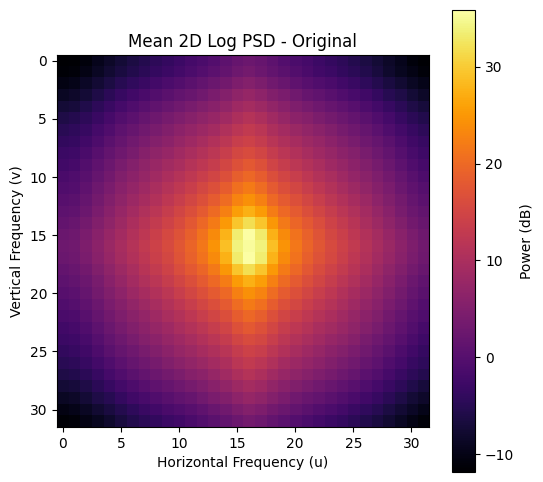

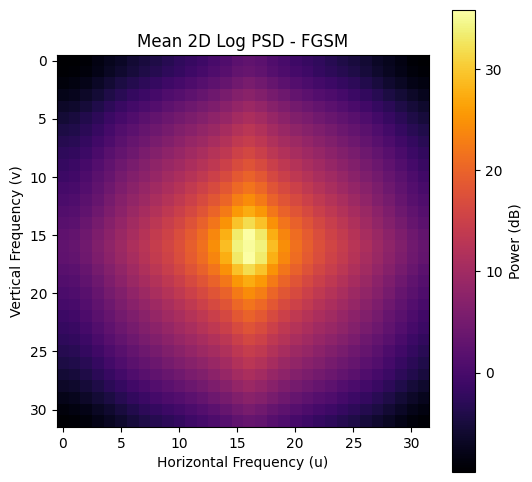

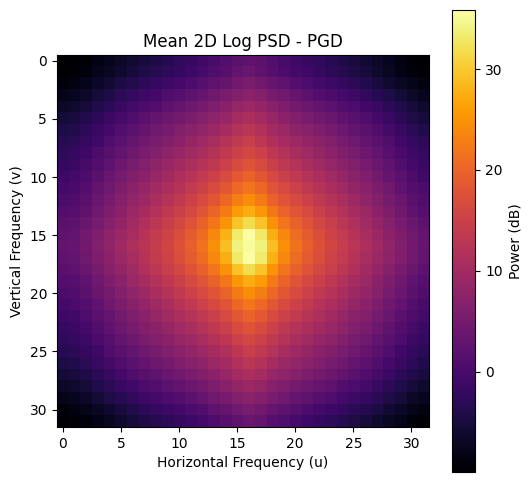

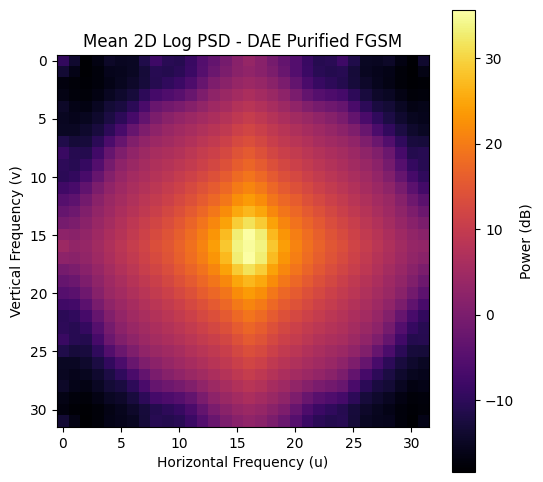

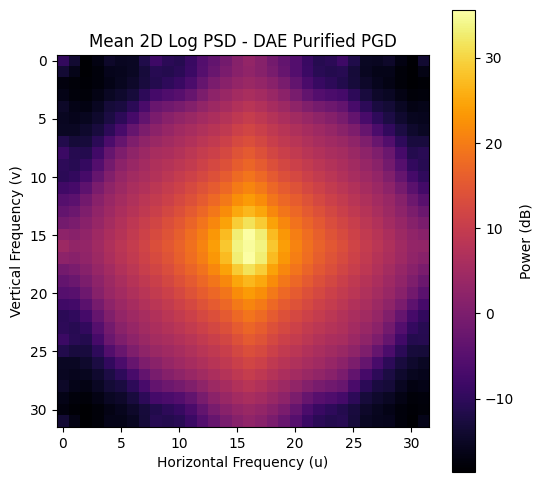

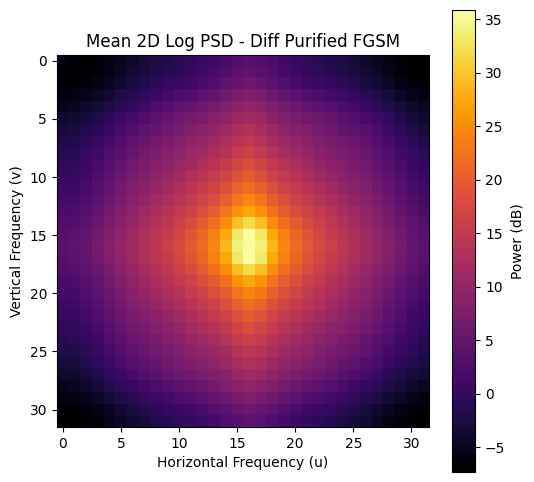

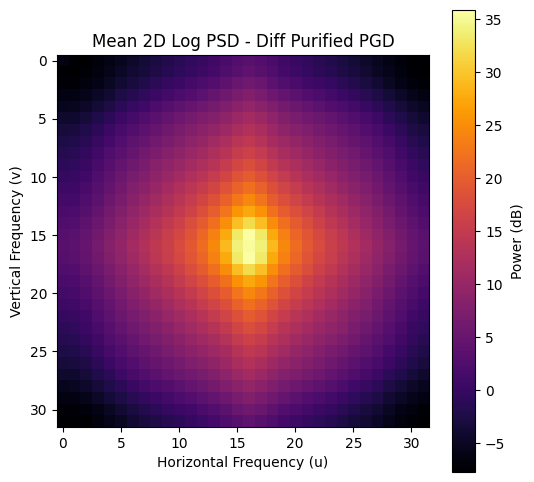

In [15]:
# Extract the underlying image tensors for plotting
original_images, _ = original_loader.dataset.tensors
fgsm_images, _ = fgsm_loader.dataset.tensors
pgd_images, _ = pgd_loader.dataset.tensors
dae_purified_fgsm_images, _ = dae_purified_fgsm_loader.dataset.tensors
dae_purified_pgd_images, _ = dae_purified_pgd_loader.dataset.tensors
diff_purified_fgsm_images, _ = diff_purified_fgsm_loader.dataset.tensors
diff_purified_pgd_images, _ = diff_purified_pgd_loader.dataset.tensors

# Instantiate the analyzer once
analyzer = SpectralAnalyzer(spatial_shape=(32, 32), device=device)

# Plot 2D heatmaps (automatically averages the whole batch)
analyzer.plot_2d(original_images, title="Mean 2D Log PSD - Original")
analyzer.plot_2d(fgsm_images, title="Mean 2D Log PSD - FGSM")
analyzer.plot_2d(pgd_images, title="Mean 2D Log PSD - PGD")
analyzer.plot_2d(dae_purified_fgsm_images, title="Mean 2D Log PSD - DAE Purified FGSM")
analyzer.plot_2d(dae_purified_pgd_images, title="Mean 2D Log PSD - DAE Purified PGD")
analyzer.plot_2d(diff_purified_fgsm_images, title="Mean 2D Log PSD - Diff Purified FGSM")
analyzer.plot_2d(diff_purified_pgd_images, title="Mean 2D Log PSD - Diff Purified PGD")

In [16]:
# Compare their 1D profiles on the same plot
dae_image_label_dict = {"Original": original_images, "FGSM": fgsm_images, "PGD": pgd_images, "DAE Purified FGSM": dae_purified_fgsm_images, "DAE Purified PGD": dae_purified_pgd_images}
diff_image_label_dict = {"Original": original_images, "FGSM": fgsm_images, "PGD": pgd_images, "Diff Purified FGSM": diff_purified_fgsm_images, "Diff Purified PGD": diff_purified_pgd_images}

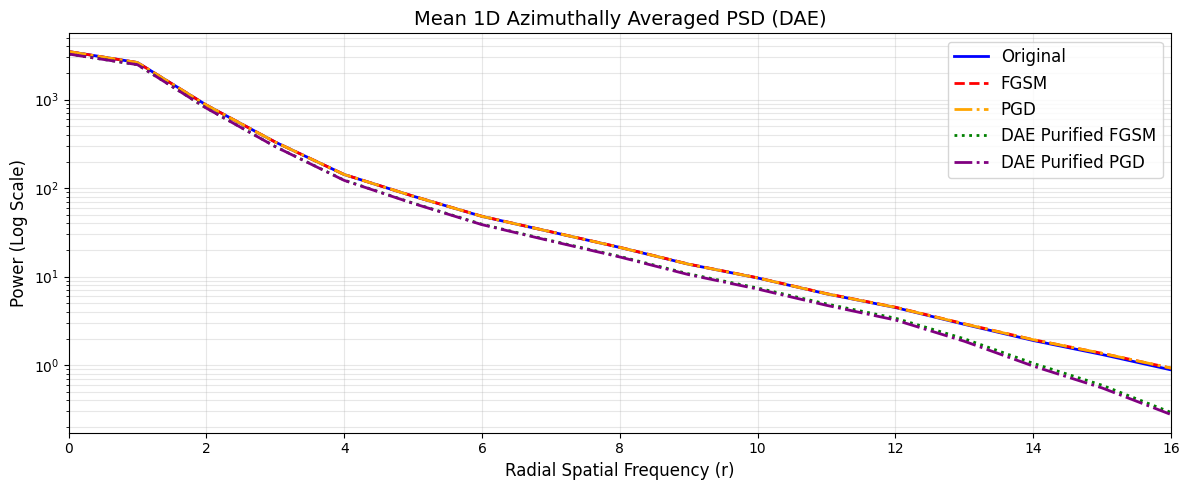

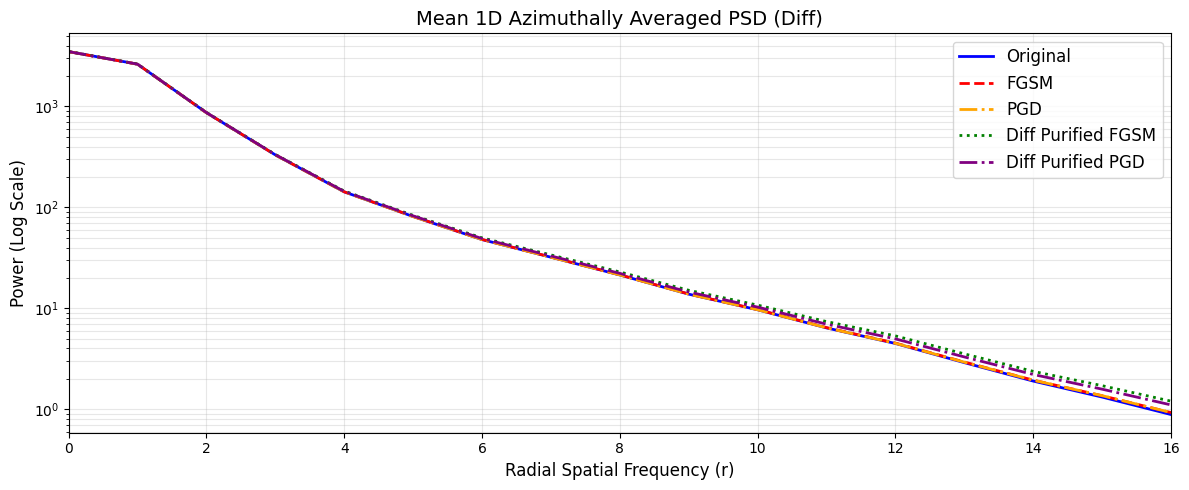

/Users/austinb.dev.bc/Projects/gap/src/gap/spectral.py:228: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  plt.ylim(bottom=0, top=100)


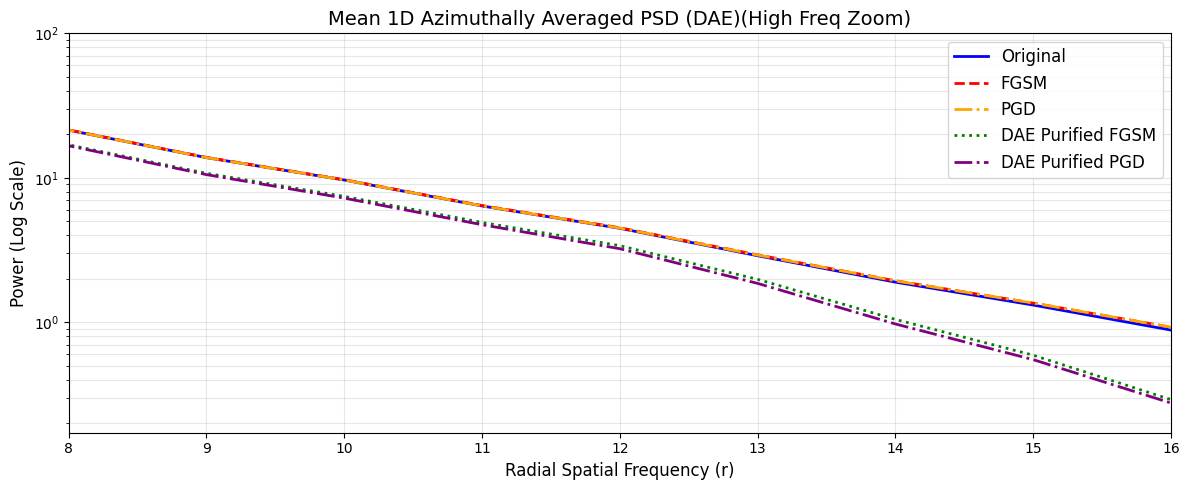

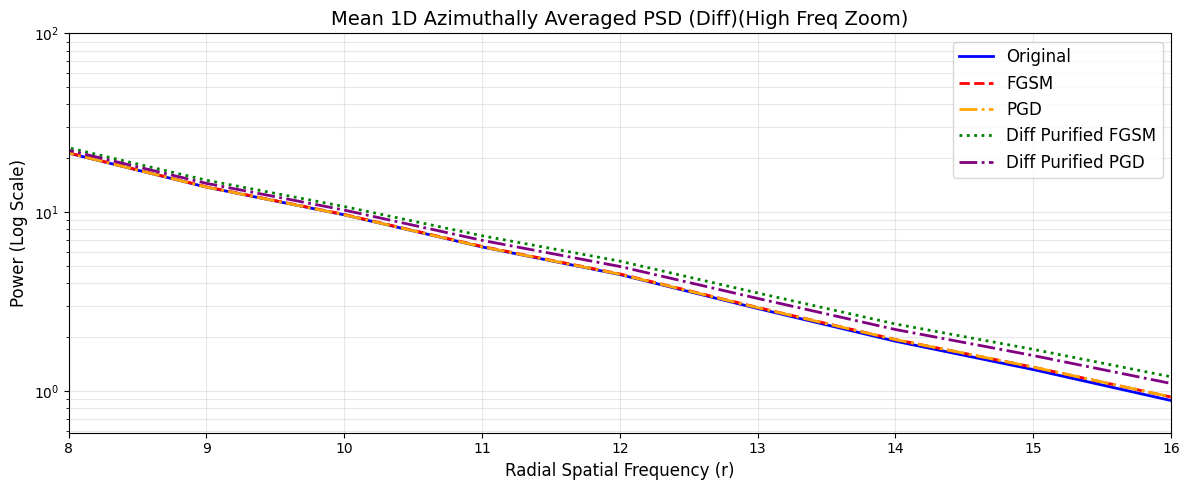

In [ ]:
analyzer.plot_1d(dae_image_label_dict, title="Mean 1D Azimuthally Averaged PSD (DAE)")
analyzer.plot_1d(diff_image_label_dict, title="Mean 1D Azimuthally Averaged PSD (Diff)")

# Compare their 1D profiles on the same plot
analyzer.plot_1d(dae_image_label_dict, title="Mean 1D Azimuthally Averaged PSD (DAE)", zoom_high_freq=True)
analyzer.plot_1d(diff_image_label_dict, title="Mean 1D Azimuthally Averaged PSD (Diff)", zoom_high_freq=True )


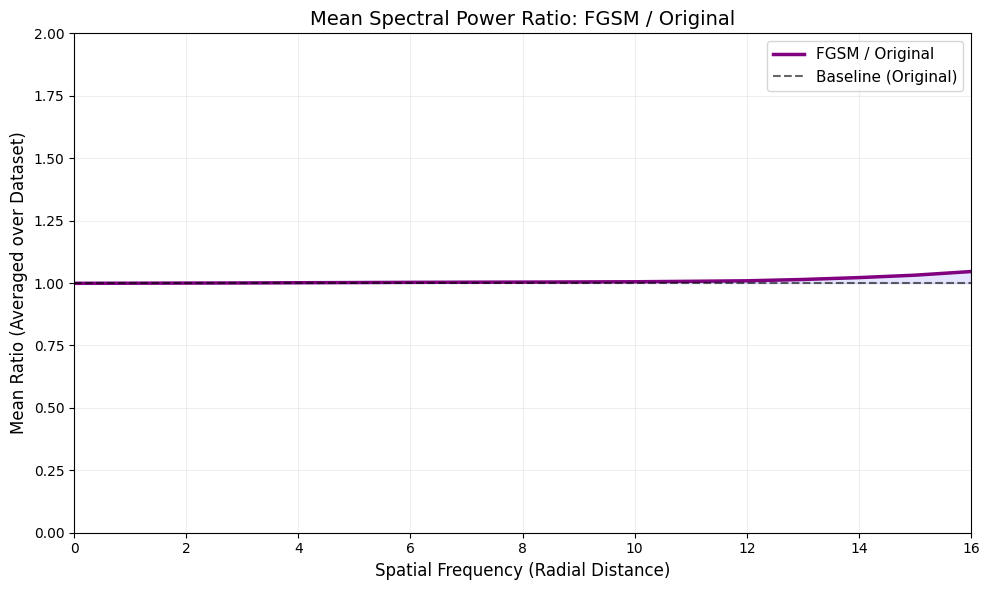

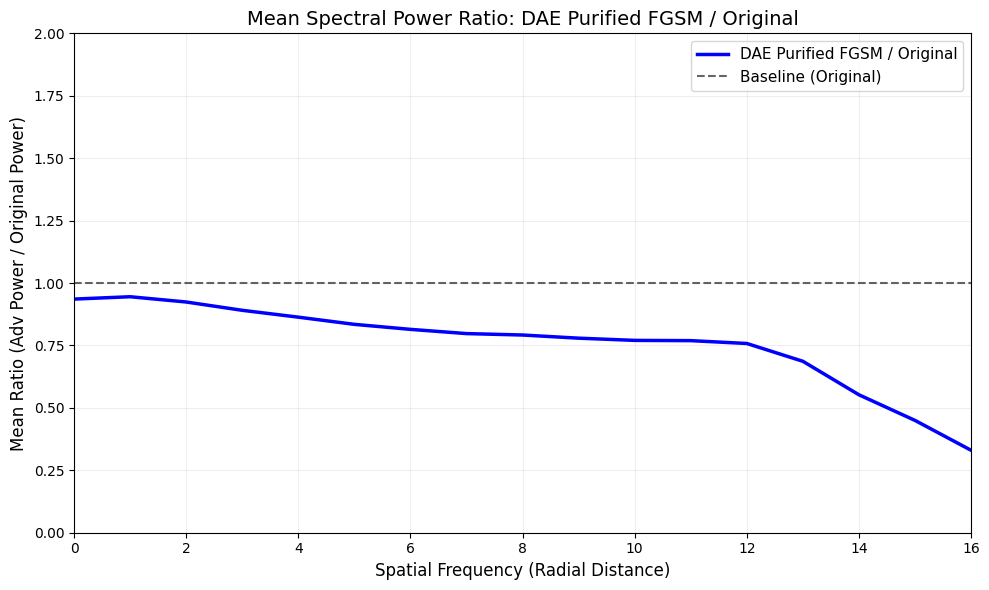

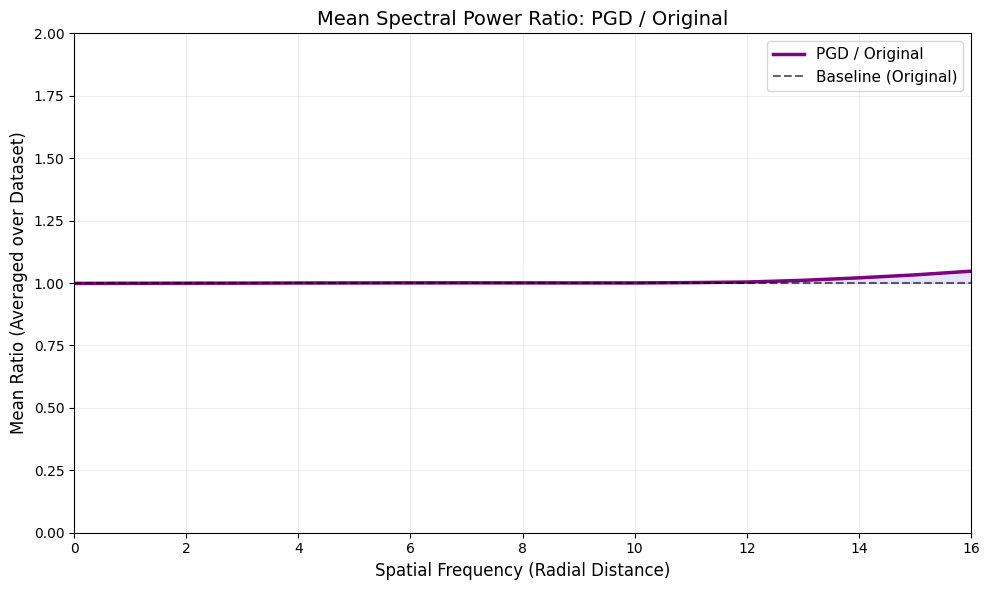

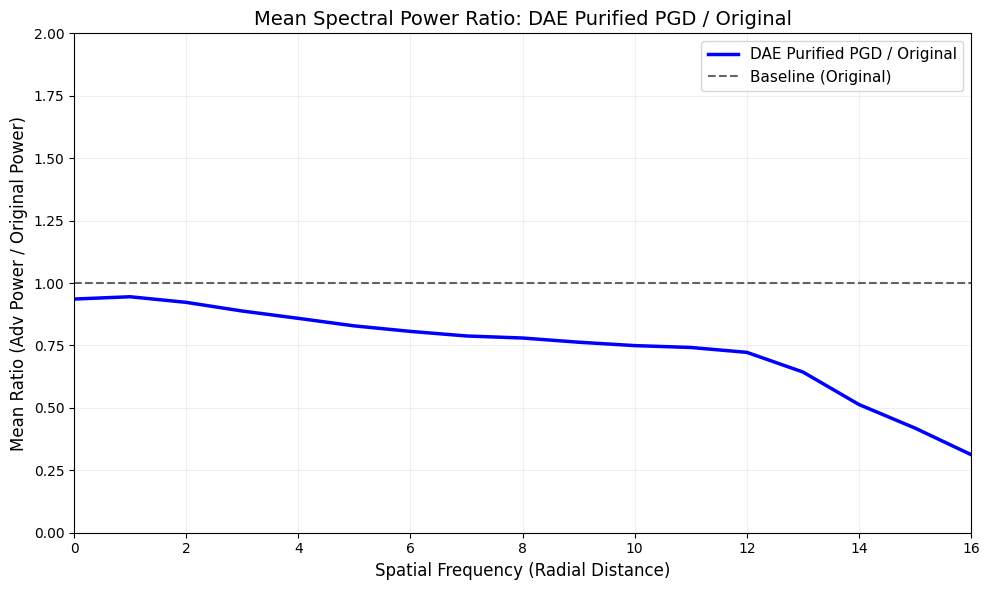

In [16]:
analyzer.plot_1d_ratio(original_images, fgsm_images, dae_purified_fgsm_images, label_21="FGSM / Original", label_31="DAE Purified FGSM / Original")
analyzer.plot_1d_ratio(original_images, pgd_images, dae_purified_pgd_images, label_21="PGD / Original", label_31="DAE Purified PGD / Original")

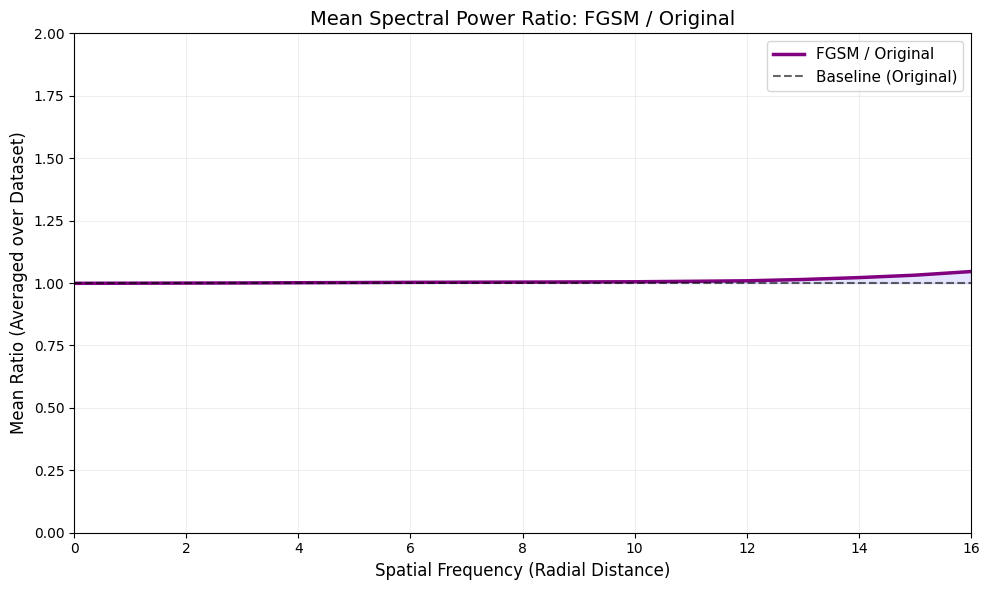

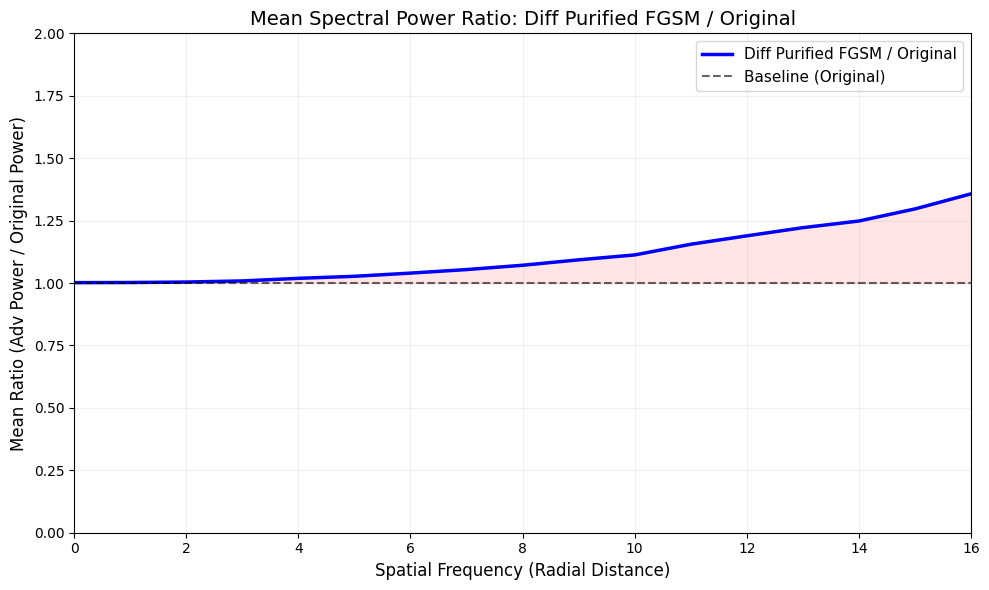

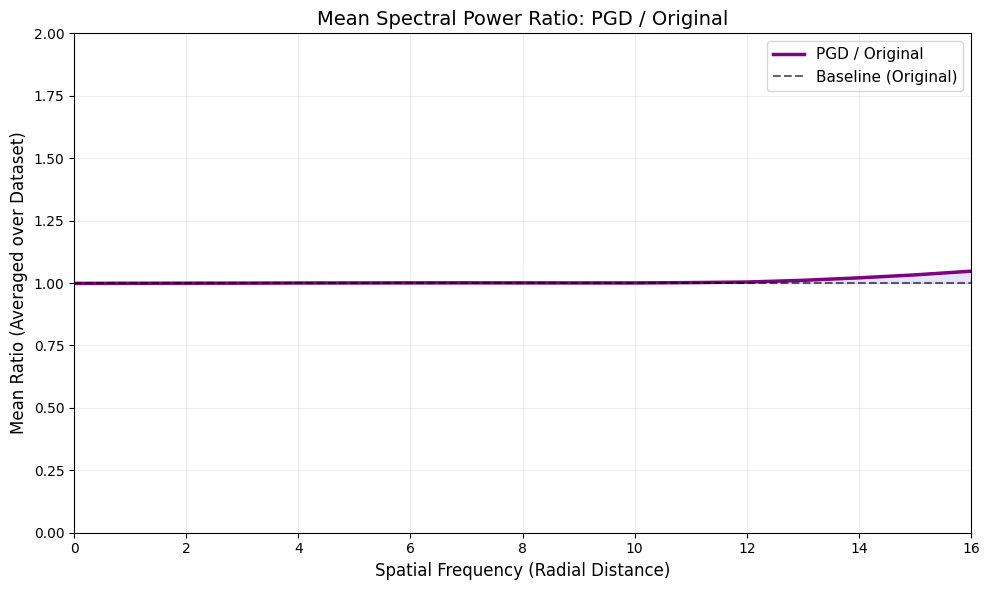

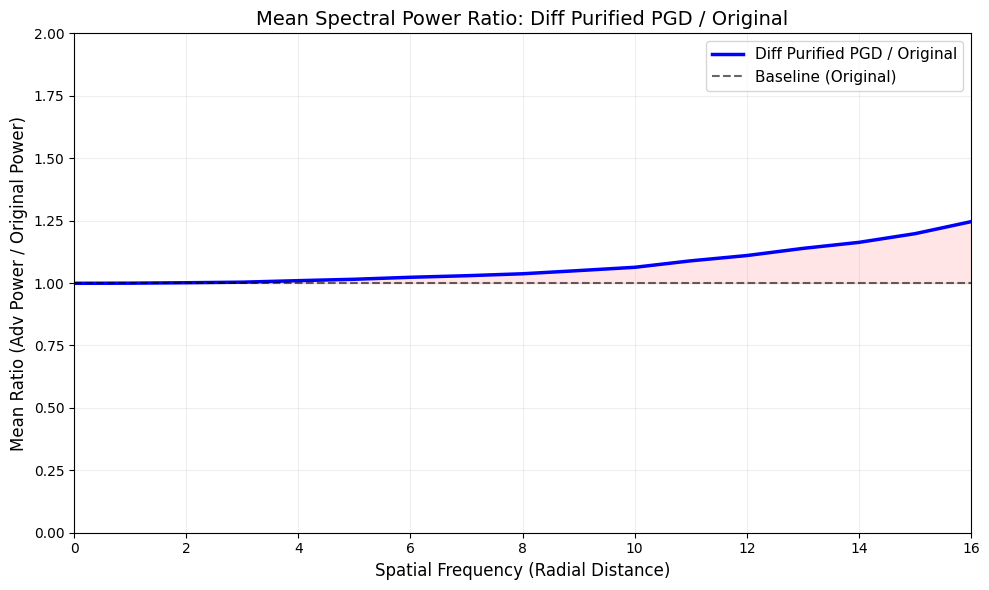

In [18]:
analyzer.plot_1d_ratio(original_images, fgsm_images, diff_purified_fgsm_images, label_21="FGSM / Original", label_31="Diff Purified FGSM / Original")
analyzer.plot_1d_ratio(original_images, pgd_images, diff_purified_pgd_images, label_21="PGD / Original", label_31="Diff Purified PGD / Original")

In [19]:
analyzer.print_spectral_stats(dae_image_label_dict)
analyzer.print_spectral_stats(diff_image_label_dict)

Dataset    | Mean Low-Freq Power (dB) | Mean High-Freq Power (dB)
-------------------------------------------------------
Original   | 24.5933              | 6.3524              
FGSM       | 24.5973              | 6.4202              
PGD        | 24.5922              | 6.4088              
DAE Purified FGSM | 24.0086              | 4.3445              
DAE Purified PGD | 23.9870              | 4.1464              
Dataset    | Mean Low-Freq Power (dB) | Mean High-Freq Power (dB)
-------------------------------------------------------
Original   | 24.5933              | 6.3524              
FGSM       | 24.5973              | 6.4202              
PGD        | 24.5922              | 6.4088              
Diff Purified FGSM | 24.6762              | 7.1096              
Diff Purified PGD | 24.6361              | 6.8430              


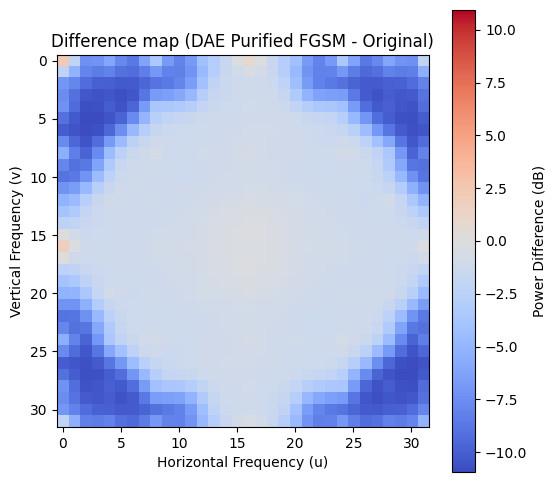

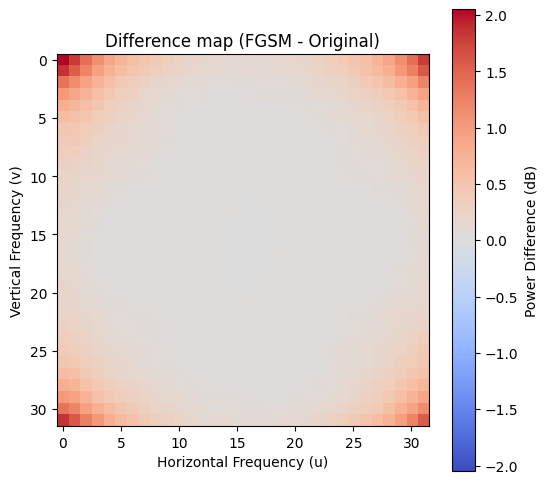

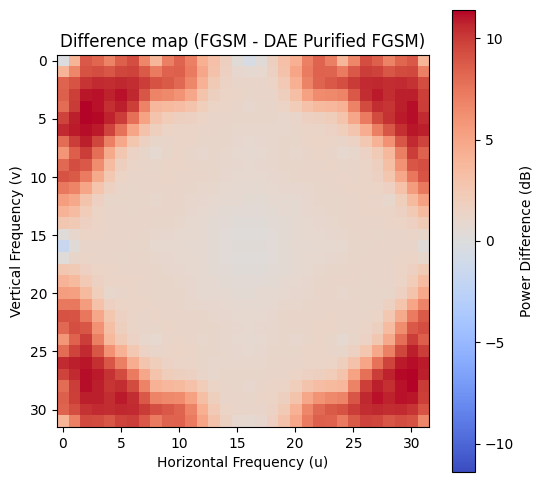

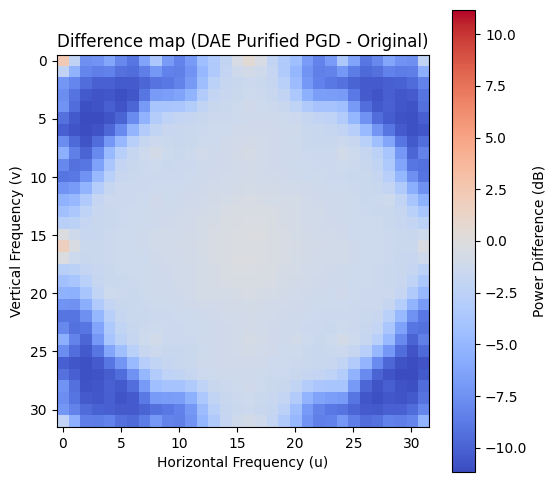

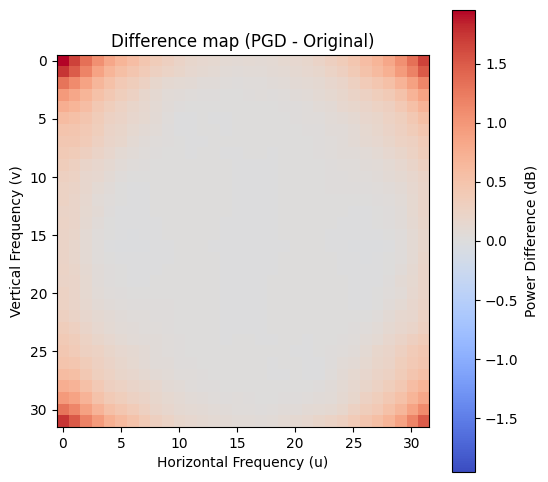

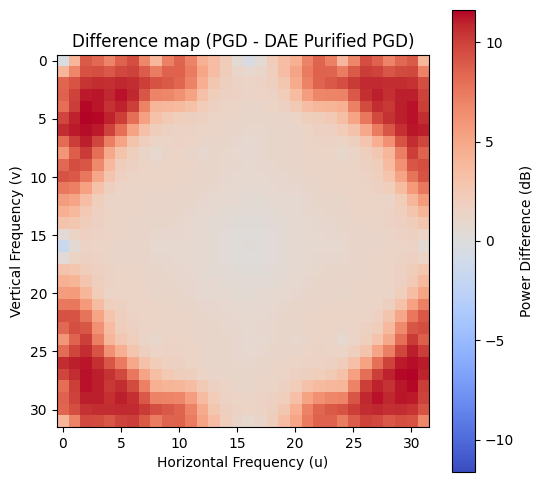

In [20]:
analyzer.plot_2d_difference(
    images_1=original_images,
    images_3=fgsm_images,
    images_2=dae_purified_fgsm_images,
    title_31="Difference map (FGSM - Original)",
    title_21="Difference map (DAE Purified FGSM - Original)",
    title_32="Difference map (FGSM - DAE Purified FGSM)"
)

analyzer.plot_2d_difference(
    images_1=original_images,
    images_3=pgd_images,
    images_2=dae_purified_pgd_images,
    title_31="Difference map (PGD - Original)",
    title_21="Difference map (DAE Purified PGD - Original)",
    title_32="Difference map (PGD - DAE Purified PGD)"
)

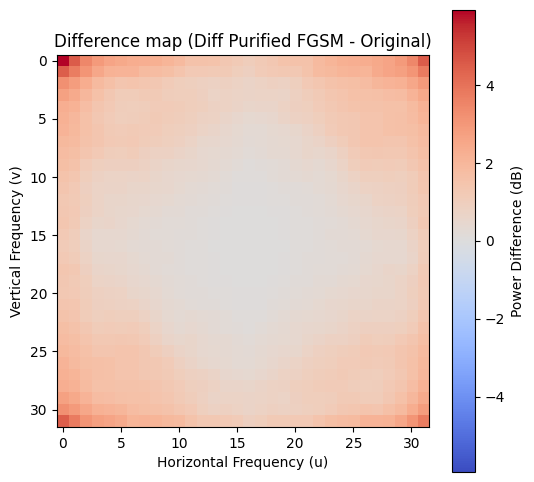

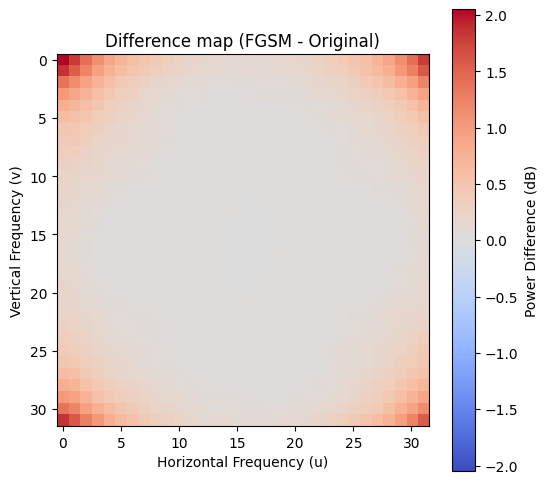

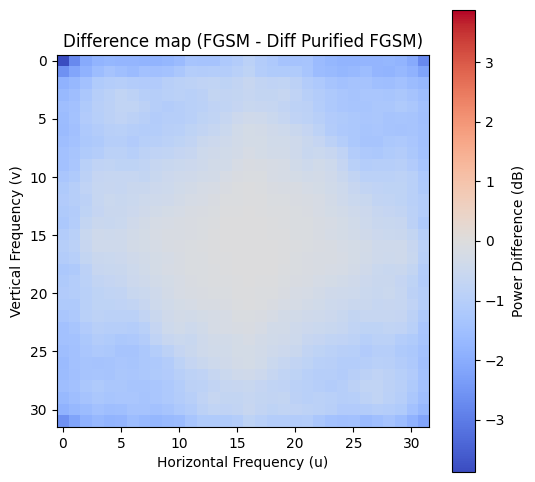

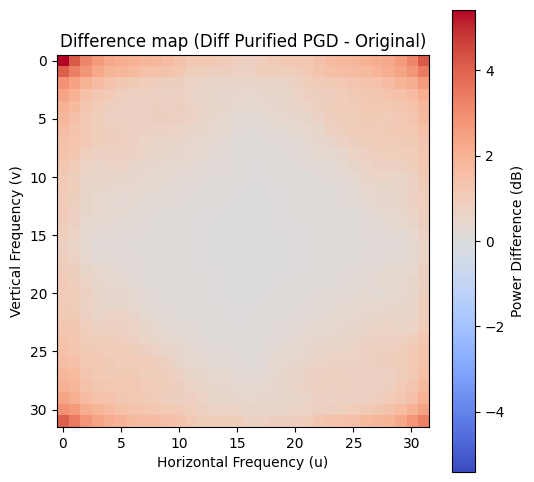

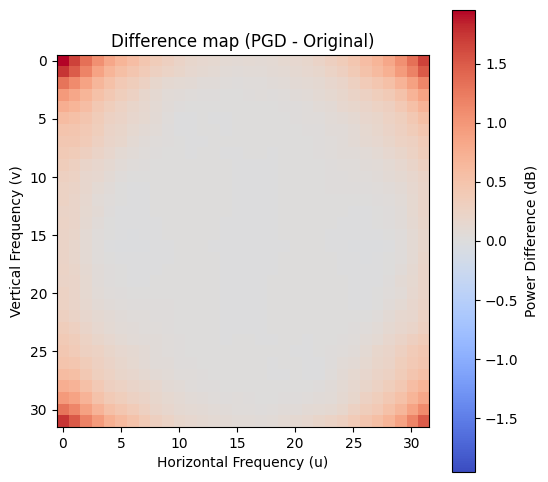

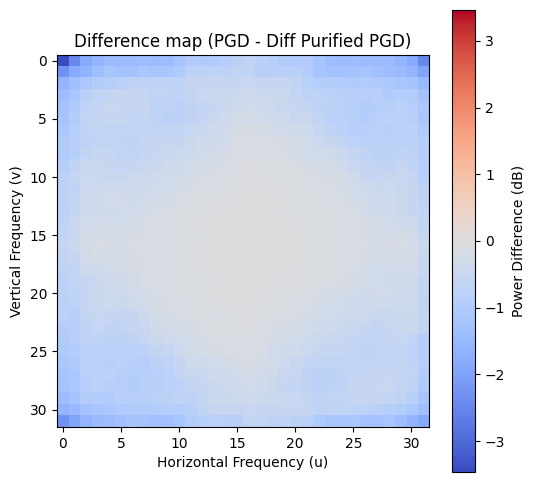

In [21]:
analyzer.plot_2d_difference(
    images_1=original_images,
    images_3=fgsm_images,
    images_2=diff_purified_fgsm_images,
    title_31="Difference map (FGSM - Original)",
    title_21="Difference map (Diff Purified FGSM - Original)",
    title_32="Difference map (FGSM - Diff Purified FGSM)"
)

analyzer.plot_2d_difference(
    images_1=original_images,
    images_3=pgd_images,
    images_2=diff_purified_pgd_images,
    title_31="Difference map (PGD - Original)",
    title_21="Difference map (Diff Purified PGD - Original)",
    title_32="Difference map (PGD - Diff Purified PGD)"
)


In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import random

def unnormalize_and_prep(tensor_img, mean=None, std=None):
    """
    Formats a single image tensor for Matplotlib. 
    If mean/std are None (unnormalized data), it just clamps and permutes.
    """
    img = tensor_img.clone().detach().cpu()
    
    # Only un-normalize if mean/std are provided
    if mean is not None and std is not None:
        for t, m, s in zip(img, mean, std):
            t.mul_(s).add_(m)
        
    img = torch.clamp(img, 0.0, 1.0)
    return img.permute(1, 2, 0).numpy()

def find_specific_samples(model, original_imgs, fgsm_imgs, pgd_imgs, dae_fgsm, diff_fgsm, labels, device='cuda'):
    model.eval()
    model.to(device)
    
    with torch.no_grad():
        def get_preds(imgs):
            return model(imgs.to(device)).argmax(dim=1)

        pred_orig = get_preds(original_imgs)
        pred_fgsm = get_preds(fgsm_imgs)
        pred_pgd = get_preds(pgd_imgs)
        pred_dae = get_preds(dae_fgsm)
        pred_diff = get_preds(diff_fgsm)
        target = labels.to(device)

        mask = (pred_orig == target) & \
               (pred_fgsm != target) & \
               (pred_pgd != target) & \
               (pred_dae == target) & \
               (pred_diff == target)

        indices = torch.where(mask)[0].cpu().tolist()
    
    return indices, (pred_orig, pred_fgsm, pred_pgd, pred_dae, pred_diff)

def comparison_grid(model, idx=None, dataset_name="cifar10"):
    # Device setup
    if torch.backends.mps.is_available():
        device = torch.device("mps")
    elif torch.cuda.is_available():
        device = torch.device("cuda")
    else:
        device = torch.device("cpu")

    model.to(device)
    model.eval()
    
    clean_imgs, labels = original_loader.dataset.tensors
    fgsm_imgs, _ = fgsm_loader.dataset.tensors
    pgd_imgs, _ = pgd_loader.dataset.tensors
    
    # Using FGSM versions for the purified columns (as in your Pets logic)
    dae_fgsm = dae_purified_fgsm_images
    diff_fgsm = diff_purified_fgsm_images

    matching_indices, all_preds = find_specific_samples(
        model, clean_imgs, fgsm_imgs, pgd_imgs, dae_fgsm, diff_fgsm, labels, device
    )

    if not matching_indices:
        print("No samples found matching those exact criteria!")
        return

    # Use provided idx if it matches, otherwise grab a valid one
    if idx not in matching_indices:
        idx = random.choice(matching_indices)
    
    CIFAR10_CLASSES = {
        0: "airplane", 1: "automobile", 2: "bird", 3: "cat", 4: "deer",
        5: "dog", 6: "frog", 7: "horse", 8: "ship", 9: "truck"
    }

    imgs = [
        unnormalize_and_prep(clean_imgs[idx], None, None),
        unnormalize_and_prep(fgsm_imgs[idx], None, None),
        unnormalize_and_prep(pgd_imgs[idx], None, None),
        unnormalize_and_prep(dae_fgsm[idx], None, None),
        unnormalize_and_prep(diff_fgsm[idx], None, None)
    ]

    titles = [
        f"Original\n(True: {CIFAR10_CLASSES[labels[idx].item()]})",
        f"FGSM\n(Pred: {CIFAR10_CLASSES[all_preds[1][idx].item()]})",
        f"PGD\n(Pred: {CIFAR10_CLASSES[all_preds[2][idx].item()]})",
        f"DAE Pure\n(Pred: {CIFAR10_CLASSES[all_preds[3][idx].item()]})",
        f"Diff Pure\n(Pred: {CIFAR10_CLASSES[all_preds[4][idx].item()]})"
    ]

    # 6. Plotting
    fig, axes = plt.subplots(1, 5, figsize=(20, 5))
    for i, (ax, img, title) in enumerate(zip(axes, imgs, titles)):
        ax.imshow(img)
        # Match your requested color logic
        color = "red" if ("FGSM" in title or "PGD" in title) else "green"
        ax.set_title(title, fontsize=12, fontweight="bold", color=color)
        ax.axis("off")

    plt.tight_layout()
    plt.savefig(f"../figs/{dataset_name}/images/image_comparison_grid_{idx}.png")
    plt.show()


Generating visual comparison grid...
[3925 5918 6396 6232 2816]


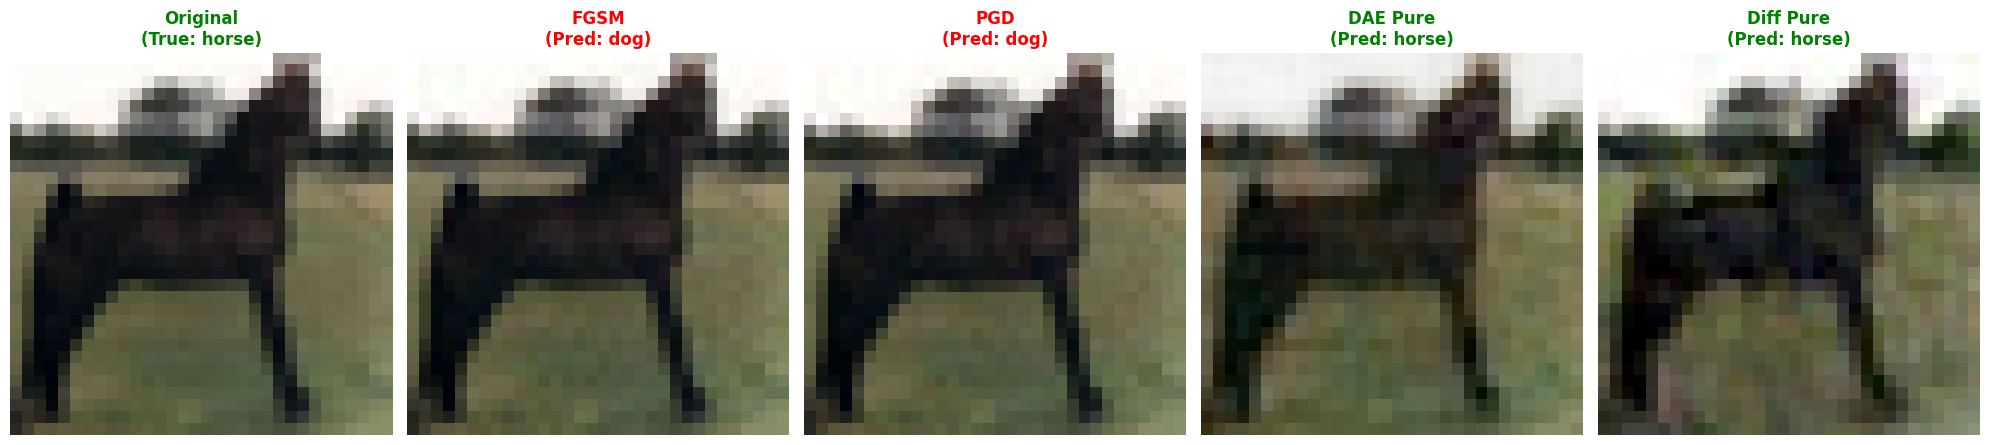

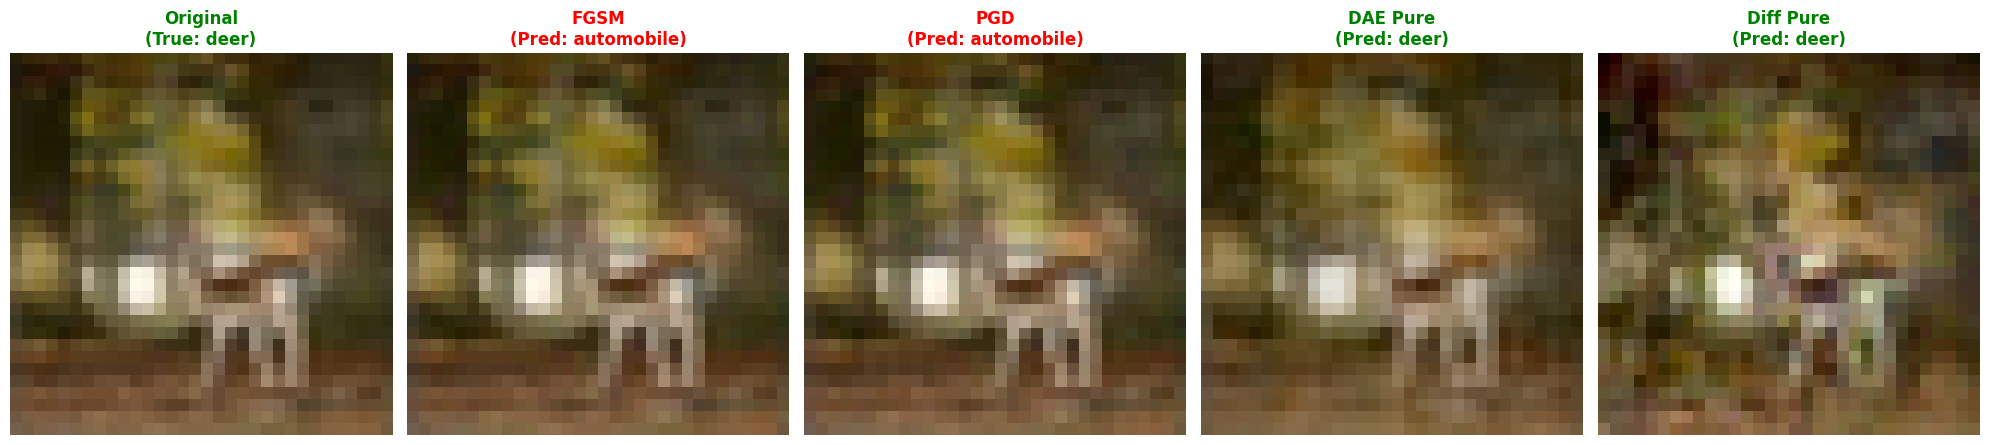

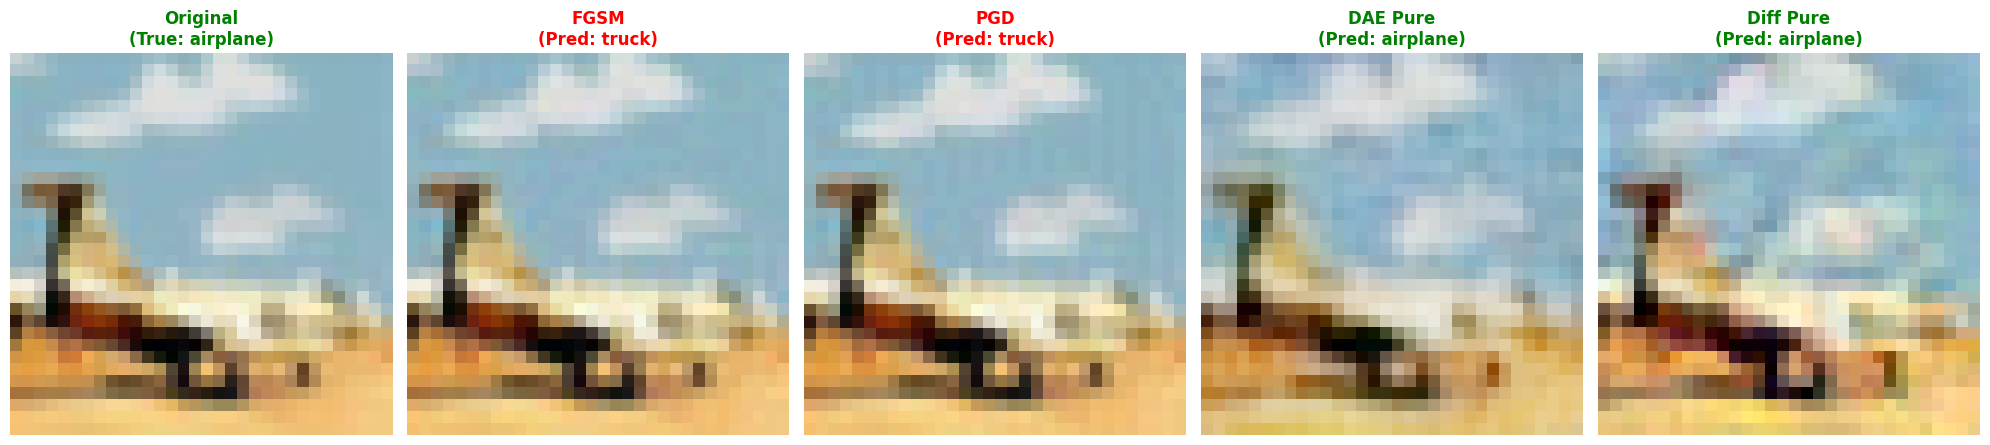

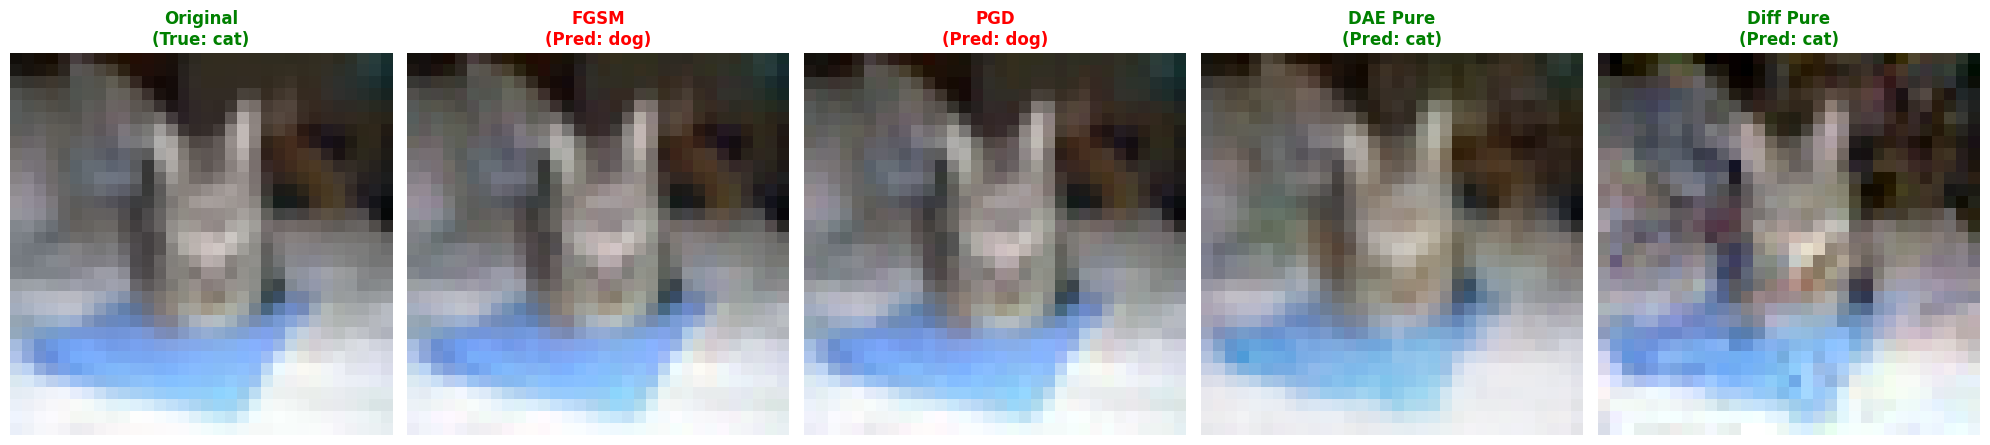

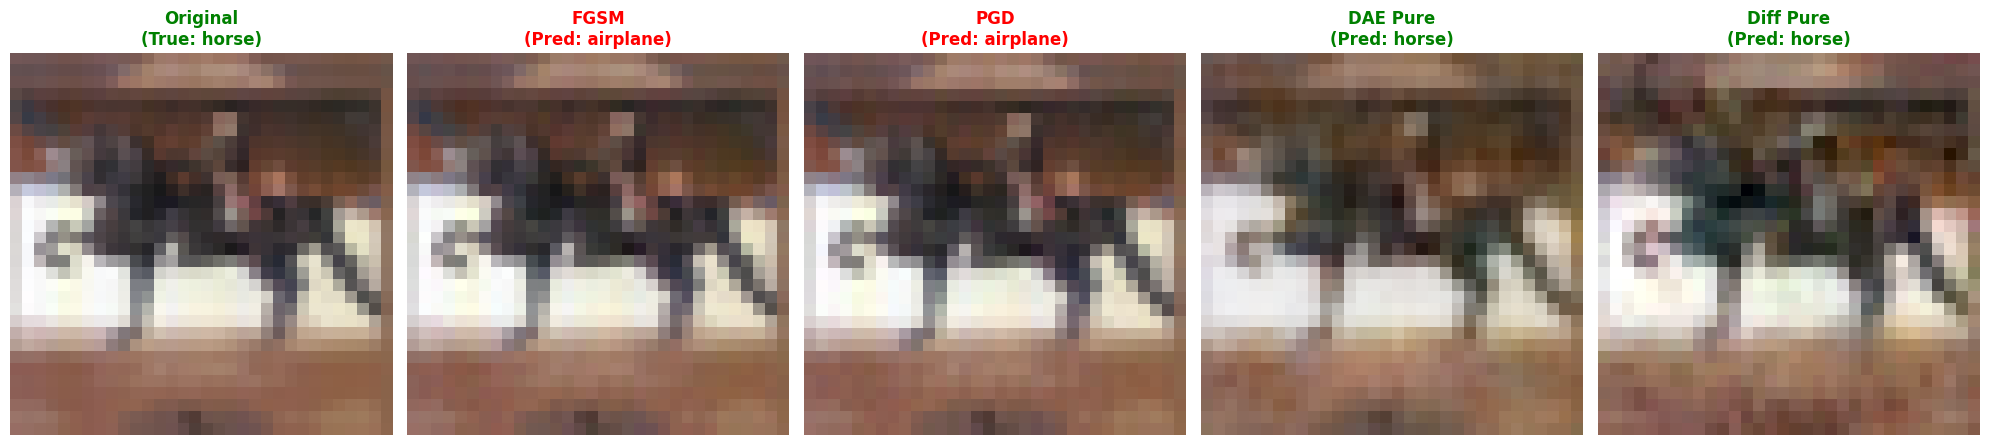

In [19]:
print("\nGenerating visual comparison grid...")

idxs = np.random.randint(0, len(original_loader.dataset.tensors[0]) - 1, 5)
print(idxs)
for idx in idxs:
    comparison_grid(clf_trained_model, idx)